In [21]:
# Importar bibliotecas necesarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configurar opciones de visualización
pd.set_option('display.max_rows', None)

In [28]:
# Descargar datos de Amazon (AMZN) desde 2020-01-01 hasta 2021-12-31
amzn = yf.download('AMZN', start='2020-01-01', end='2022-01-01', progress=False)

# Mostrar los primeros registros
print("Primeros registros de los datos de AMZN:")
print(amzn.head())
print(f"\nÚltimos registros de los datos de AMZN:")
print(amzn.tail())
print(f"\nTotal de registros: {len(amzn)}")

Primeros registros de los datos de AMZN:
Price           Close       High        Low       Open    Volume
Ticker           AMZN       AMZN       AMZN       AMZN      AMZN
Date                                                            
2020-01-02  94.900497  94.900497  93.207497  93.750000  80580000
2020-01-03  93.748497  94.309998  93.224998  93.224998  75288000
2020-01-06  95.143997  95.184502  93.000000  93.000000  81236000
2020-01-07  95.343002  95.694504  94.601997  95.224998  80898000
2020-01-08  94.598503  95.550003  94.321999  94.902000  70160000

Últimos registros de los datos de AMZN:
Price            Close        High         Low        Open    Volume
Ticker            AMZN        AMZN        AMZN        AMZN      AMZN
Date                                                                
2021-12-27  169.669495  172.942993  169.215500  171.037003  58688000
2021-12-28  170.660995  172.175995  169.135498  170.182495  54638000
2021-12-29  169.201004  171.212006  168.600494  170.8

In [29]:
# Calcular la Media Móvil Exponencial (EMA) para 5 días y 20 días
amzn['EMA_5'] = amzn['Close'].ewm(span=5, adjust=False).mean()
amzn['EMA_20'] = amzn['Close'].ewm(span=20, adjust=False).mean()

# Mostrar los últimos registros con las EMAs calculadas
print("Últimos registros con EMA de 5 y 20 días:")
print(amzn[['Close', 'EMA_5', 'EMA_20']].tail(10))

Últimos registros con EMA de 5 y 20 días:
Price            Close       EMA_5      EMA_20
Ticker            AMZN                        
Date                                          
2021-12-17  170.017502  170.605879  172.803620
2021-12-20  167.078995  169.430251  172.258418
2021-12-21  170.417007  169.759170  172.083045
2021-12-22  171.037003  170.185114  171.983422
2021-12-23  171.068497  170.479575  171.896286
2021-12-27  169.669495  170.209548  171.684211
2021-12-28  170.660995  170.360031  171.586762
2021-12-29  169.201004  169.973688  171.359547
2021-12-30  168.644501  169.530626  171.100971
2021-12-31  166.716995  168.592749  170.683450


In [30]:
# Obtener el valor de EMA de 5 días para 2021-12-31
fecha_objetivo = '2021-12-31'

# Verificar si la fecha existe en el índice
if fecha_objetivo in amzn.index:
    ema5_2021_12_31 = amzn.loc[fecha_objetivo, 'EMA_5']
    print(f"✓ Respuesta a la pregunta:")
    print(f"  La Media Móvil Exponencial de 5 días para {fecha_objetivo} es: ${ema5_2021_12_31:.2f}")
else:
    # Si no existe la fecha exacta, buscar la fecha más cercana
    amzn_reset = amzn.reset_index()
    amzn_reset['Date'] = pd.to_datetime(amzn_reset['Date'])
    fecha_obj = pd.to_datetime(fecha_objetivo)
    idx_cercano = (amzn_reset['Date'] - fecha_obj).abs().argmin()
    fecha_cercana = amzn_reset.loc[idx_cercano, 'Date'].strftime('%Y-%m-%d')
    ema5_cercano = amzn_reset.loc[idx_cercano, 'EMA_5']
    print(f"✓ Respuesta a la pregunta:")
    print(f"  La fecha exacta {fecha_objetivo} no existe en los datos.")
    print(f"  La fecha más cercana es: {fecha_cercana}")
    print(f"  La Media Móvil Exponencial de 5 días para {fecha_cercana} es: ${ema5_cercano:.2f}")

✓ Respuesta a la pregunta:
  La Media Móvil Exponencial de 5 días para 2021-12-31 es: $168.59


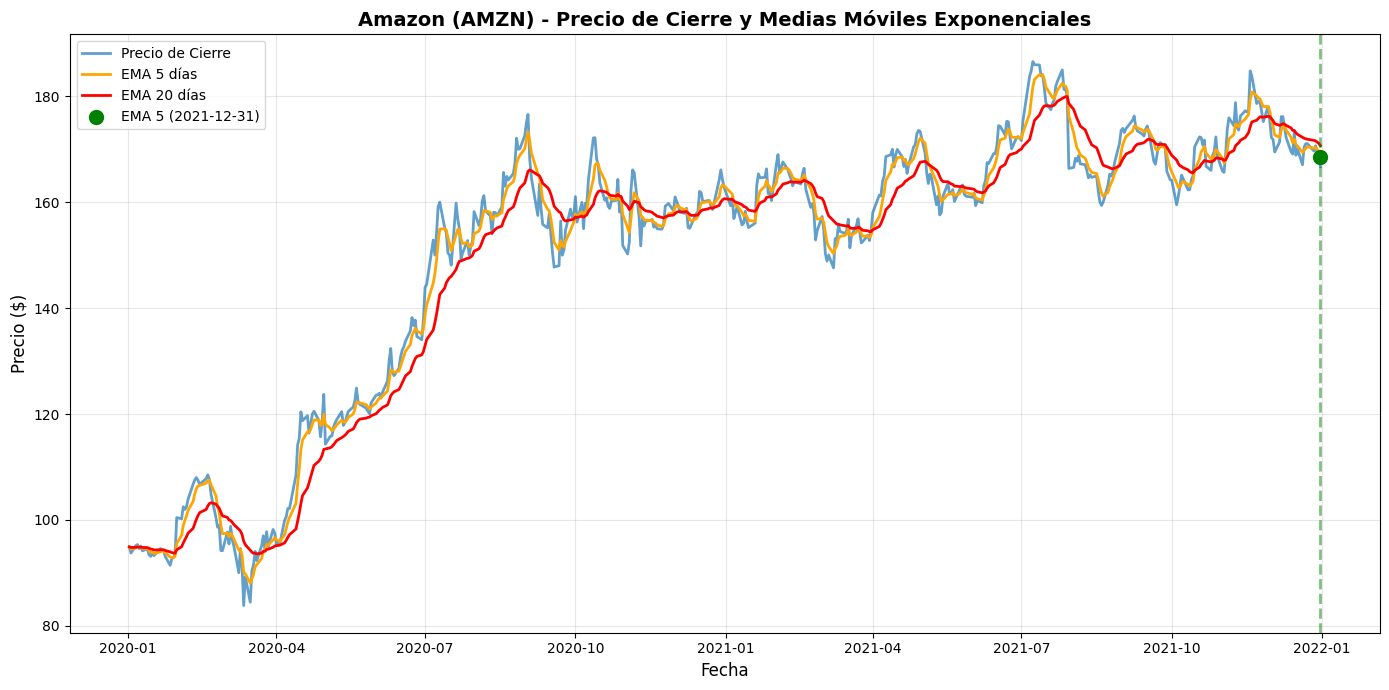

In [31]:
# Visualizar el precio de cierre y las medias móviles exponenciales
plt.figure(figsize=(14, 7))
plt.plot(amzn.index, amzn['Close'], label='Precio de Cierre', linewidth=2, alpha=0.7)
plt.plot(amzn.index, amzn['EMA_5'], label='EMA 5 días', linewidth=2, color='orange')
plt.plot(amzn.index, amzn['EMA_20'], label='EMA 20 días', linewidth=2, color='red')

# Marcar la fecha objetivo
if fecha_objetivo in amzn.index:
    plt.axvline(x=pd.to_datetime(fecha_objetivo), color='green', linestyle='--', alpha=0.5, linewidth=2)
    plt.scatter([pd.to_datetime(fecha_objetivo)], [amzn.loc[fecha_objetivo, 'EMA_5']], 
               color='green', s=100, zorder=5, label=f'EMA 5 ({fecha_objetivo})')

plt.title('Amazon (AMZN) - Precio de Cierre y Medias Móviles Exponenciales', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pregunta 2: Gráfico de EMAs entre Mayo 1 y Agosto 1

In [32]:
# Filtrar datos entre mayo 1 y agosto 1
fecha_inicio = '2020-05-01'
fecha_fin = '2020-08-01'

amzn_filtrado = amzn.loc[fecha_inicio:fecha_fin].copy()

# Mostrar información del período seleccionado
print(f"Datos de AMZN entre {fecha_inicio} y {fecha_fin}")
print(f"Total de registros en el período: {len(amzn_filtrado)}")
print(f"\nPrimeros registros:")
print(amzn_filtrado[['Close', 'EMA_5', 'EMA_20']].head())
print(f"\nÚltimos registros:")
print(amzn_filtrado[['Close', 'EMA_5', 'EMA_20']].tail())

Datos de AMZN entre 2020-05-01 y 2020-08-01
Total de registros en el período: 64

Primeros registros:
Price            Close       EMA_5      EMA_20
Ticker            AMZN                        
Date                                          
2020-05-01  114.302002  118.068586  113.402362
2020-05-04  115.799500  117.312224  113.630661
2020-05-05  115.889999  116.838149  113.845836
2020-05-06  117.563004  117.079767  114.199852
2020-05-07  118.380501  117.513345  114.598009

Últimos registros:
Price            Close       EMA_5      EMA_20
Ticker            AMZN                        
Date                                          
2020-07-27  152.760498  152.373576  149.407587
2020-07-28  150.016495  151.587882  149.465578
2020-07-29  151.676498  151.617421  149.676142
2020-07-30  152.593994  151.942945  149.954033
2020-07-31  158.233994  154.039961  150.742600


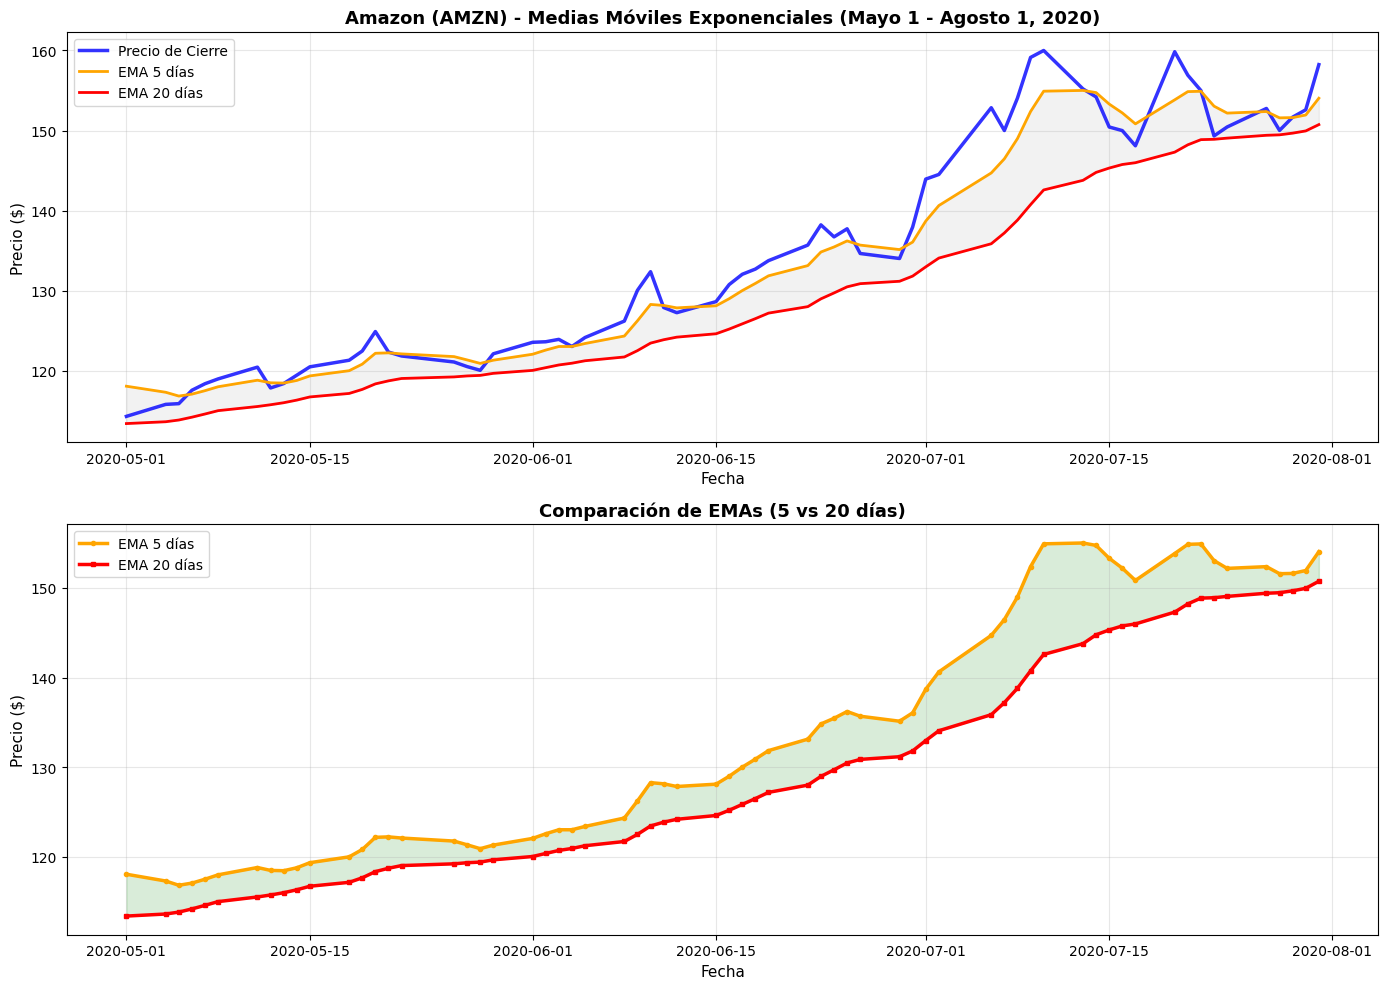


ANÁLISIS DE MEDIAS MÓVILES EXPONENCIALES
Período: Mayo 1, 2020 - Agosto 1, 2020

EMA 5 días:
  Mínimo: $116.84
  Máximo: $155.01
  Promedio: $133.75

EMA 20 días:
  Mínimo: $113.40
  Máximo: $150.74
  Promedio: $129.26

Diferencia promedio (EMA 5 - EMA 20): $4.49


In [33]:
# Crear gráfico de las EMAs entre mayo 1 y agosto 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Primer gráfico: Precio de cierre y ambas EMAs
ax1.plot(amzn_filtrado.index, amzn_filtrado['Close'], label='Precio de Cierre', linewidth=2.5, alpha=0.8, color='blue')
ax1.plot(amzn_filtrado.index, amzn_filtrado['EMA_5'], label='EMA 5 días', linewidth=2, color='orange', linestyle='-')
ax1.plot(amzn_filtrado.index, amzn_filtrado['EMA_20'], label='EMA 20 días', linewidth=2, color='red', linestyle='-')
ax1.fill_between(amzn_filtrado.index, amzn_filtrado['EMA_5'], amzn_filtrado['EMA_20'], alpha=0.1, color='gray')

ax1.set_title('Amazon (AMZN) - Medias Móviles Exponenciales (Mayo 1 - Agosto 1, 2020)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Precio ($)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# Segundo gráfico: Solo las EMAs
ax2.plot(amzn_filtrado.index, amzn_filtrado['EMA_5'], label='EMA 5 días', linewidth=2.5, marker='o', markersize=3, color='orange')
ax2.plot(amzn_filtrado.index, amzn_filtrado['EMA_20'], label='EMA 20 días', linewidth=2.5, marker='s', markersize=3, color='red')
ax2.fill_between(amzn_filtrado.index, amzn_filtrado['EMA_5'], amzn_filtrado['EMA_20'], alpha=0.15, color='green')

ax2.set_title('Comparación de EMAs (5 vs 20 días)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Precio ($)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n" + "="*60)
print("ANÁLISIS DE MEDIAS MÓVILES EXPONENCIALES")
print("Período: Mayo 1, 2020 - Agosto 1, 2020")
print("="*60)
print(f"\nEMA 5 días:")
print(f"  Mínimo: ${amzn_filtrado['EMA_5'].min():.2f}")
print(f"  Máximo: ${amzn_filtrado['EMA_5'].max():.2f}")
print(f"  Promedio: ${amzn_filtrado['EMA_5'].mean():.2f}")
print(f"\nEMA 20 días:")
print(f"  Mínimo: ${amzn_filtrado['EMA_20'].min():.2f}")
print(f"  Máximo: ${amzn_filtrado['EMA_20'].max():.2f}")
print(f"  Promedio: ${amzn_filtrado['EMA_20'].mean():.2f}")
print(f"\nDiferencia promedio (EMA 5 - EMA 20): ${(amzn_filtrado['EMA_5'] - amzn_filtrado['EMA_20']).mean():.2f}")